In [15]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import math
from sklearn.linear_model import LogisticRegressionCV
from scipy.stats import ranksums
import matplotlib.image as img 

In [ ]:
#Fig 4c, written by Molly
for file in ['Tumor', 'Stroma']:
    df = pd.read_csv('fig4/fig4c/fig4c_' + file + '.csv')
    df = df.fillna(0)

    subtypes = set(df[file + ' subtype'])
    subtypes.remove(0)

    tests = set(df.columns)
    tests.remove('ID')
    tests.remove(file + ' subtype')

    c = [file + ' subtype']
    for test in tests:
        c.append(test)
        c.append('Wilcox_' + str(test))

    LR_OR = pd.DataFrame(columns = [file + 'subtype','Feature','Effect Size','Pvalue'])
    for type in subtypes:
        df['type_' + type] = np.where(df[file + ' subtype'] == type, True, False)

    for type in subtypes:
        for test in tests:
            if test != file + ' subtype':
                row = {}
                row[file + ' subtype'] = type
                clf = LogisticRegressionCV().fit(np.array(df[test]).reshape(-1, 1), np.array(df['type_' + type]))
                row['Effect Size'] = [math.exp(clf.coef_[0][0])]
                stat, p = ranksums(df[df[file + ' subtype'] == type][test], df[df[file + ' subtype'] != type][test])
                row['Pvalue'] = p
                row['Feature'] = test
                LR_OR = pd.concat([LR_OR, pd.DataFrame(row)])


    LR_OR.to_csv('fig4/fig4c/' + file + '_OR.csv', index=False)

In [ ]:
df_tumor = pd.read_csv('fig4/fig4c/tumor_OR.csv')
df_stroma = pd.read_csv('fig4/fig4c/stroma_OR.csv')

tf = pd.read_csv('fig4/fig4c/fig4c_tumor_features.csv')
sf = pd.read_csv('fig4/fig4c/fig4c_stroma_features.csv')

df_tumor = pd.merge(df_tumor, tf, how="inner", on='Feature')
df_stroma = pd.merge(df_stroma, sf, how="inner", on='Feature')

tumor_features = list(tf['Feature'])
stroma_features = list(sf['Feature'])

tumor_functions = list(tf['Function'])
stroma_functions = list(sf['Function'])

df_tumor['Effect Size'] = np.where(df_tumor['Effect Size'] > 4, 4, df_tumor['Effect Size'])
df_stroma['Effect Size'] = np.where(df_stroma['Effect Size'] > 4, 4, df_stroma['Effect Size'])

fig = px.bar(df_tumor, x="Function", y="Effect Size", color="Tumor subtype", title='Tumor Compartment')
fig.show()

fig = px.bar(df_stroma, x="Function", y="Effect Size", color="Stroma subtype", title='Stroma Compartment')
fig.show()

In [ ]:
#Fig 4d

plt.title("")

In [ ]:
#Fig 5d, written by Molly
df_8 = pd.read_csv('fig5/fig5d/supplementary_8.csv')
df_17 = pd.read_csv('fig5/fig5d/supplementary_17.csv')
sample_type = pd.read_csv('fig5/fig5d/TNBC_classification.csv')

df_TLS = df_8[df_8['Selected_samples_for_TLS_analysis (9)'] == 1]
sig_genes = list(df_17['Genes'])

df_tls_vs = pd.read_csv('fig5/fig5d/fig5d.csv')
#df_tls_vs = df_tls_vs[df_tls_vs['Gene'].isin(sig_genes)]
sig_function = pd.read_csv('fig5/fig5d/fig5d_gene_function.csv')

df_tls_vs = pd.merge(df_tls_vs, sig_function, how="outer", on='Gene')

df_tls_vs['Min FC of TLS vs. non-lymphocyte'] = df_tls_vs[['FC Fat tissue vs TLS', 'FC in situ vs TLS', 'FC Lactiferous duct vs TLS',
                           'FC Necrosis vs TLS', 'FC Tumor vs TLS', 'FC Stroma vs TLS', 'FC Vessels vs TLS']].min(axis=1)

df_tls_vs['Min FC'] = df_tls_vs[['FC Fat tissue vs TLS', 'FC in situ vs TLS', 'FC Lactiferous duct vs TLS', 'FC Lymphocyte vs TLS',
                           'FC Necrosis vs TLS', 'FC Tumor vs TLS', 'FC Stroma vs TLS', 'FC Vessels vs TLS']].min(axis=1)

df_tls_vs['Max P-value'] = df_tls_vs[['P-value Fat tissue vs TLS', 'P-value in situ vs TLS', 'P-value Lactiferous duct vs TLS', 'P-value Lymphocyte vs TLS',
                           'P-value Necrosis vs TLS', 'P-value Tumor vs TLS', 'P-value Stroma vs TLS', 'P-value Vessels vs TLS']].min(axis=1)

df_tls_vs = df_tls_vs.fillna('Non-signature gene')
df_tls_vs['Sig Gene'] = np.where(df_tls_vs['Function'] != 0, True, False)

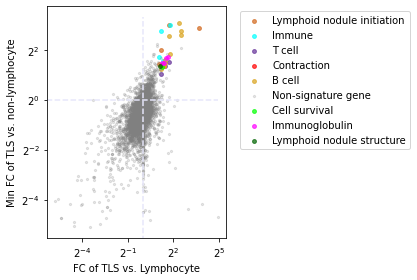

In [11]:
colors = set(['red', 'chocolate', 'goldenrod', 'darkgreen', 'lime', 'cyan', 'rebeccapurple', 'magenta'])
functions = list((set(df_tls_vs['Function'])))

for i in range(len(functions)):
    df = df_tls_vs[df_tls_vs['Function'] == functions[i]]
    if functions[i] == 'Non-signature gene':
        plt.scatter(df['FC Lymphocyte vs TLS'], df['Min FC of TLS vs. non-lymphocyte'],
                    c='grey', label=functions[i], s=5, alpha=.2)
        a = 2
    else:
        plt.scatter(df['FC Lymphocyte vs TLS'], df['Min FC of TLS vs. non-lymphocyte'],
                    c=colors.pop(), label=functions[i], s=15, alpha=.7)

plt.xscale('log', base=2)
plt.yscale('log', base=2)
plt.xlabel('FC of TLS vs. Lymphocyte')
plt.ylabel('Min FC of TLS vs. non-lymphocyte')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

plt.hlines(1, 0, 30, linestyles='dashed', colors='lavender')
plt.vlines(1, 0, 10, linestyles='dashed', colors='lavender')
plt.tight_layout()
plt.show()
plt.close()

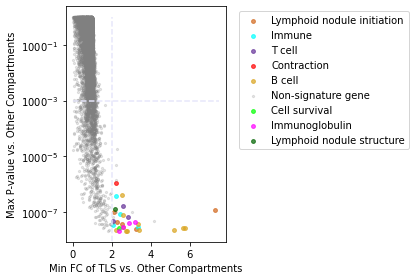

In [12]:
colors = set(['red', 'chocolate', 'goldenrod', 'darkgreen', 'lime', 'cyan', 'rebeccapurple', 'magenta'])
for i in range(len(functions)):
    df = df_tls_vs[df_tls_vs['Function'] == functions[i]]
    if functions[i] == 'Non-signature gene':
        plt.scatter(df['Min FC'], df['Max P-value'],
                    c='grey', label=functions[i], s=5, alpha=.2)
        a = 2
    else:
        plt.scatter(df['Min FC'], df['Max P-value'],
                    c=colors.pop(), label=functions[i], s=15, alpha=.7)

plt.yscale('log', base=1000)
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.xlabel('Min FC of TLS vs. Other Compartments')
plt.ylabel('Max P-value vs. Other Compartments')

plt.hlines(math.pow(10, -9), 0, 7.5, linestyles='dashed', colors='lavender')
plt.vlines(2, 0, 1, linestyles='dashed', colors='lavender')
plt.tight_layout()
plt.show()
plt.close()